In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline

In [2]:
train = pd.read_csv("data/train.csv", index_col = "id")
test = pd.read_csv("data/test.csv", index_col = "id")
submission = pd.read_csv("data/sample_submission.csv", index_col = "id")

# 1. Exploratory Data Analysis

In [3]:
train.shape, test.shape

((595212, 58), (892816, 57))

- A lot of features
- The dataset is huge

In [4]:
train.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


In [5]:
test.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
0,0,1,8,1,0,0,1,0,0,0,...,1,1,1,12,0,1,1,0,0,1
1,4,2,5,1,0,0,0,0,1,0,...,2,0,3,10,0,0,1,1,0,1
2,5,1,3,0,0,0,0,0,1,0,...,4,0,2,4,0,0,0,0,0,0
3,0,1,6,0,0,1,0,0,0,0,...,5,1,0,5,1,0,1,0,0,0
4,5,1,7,0,0,0,0,0,1,0,...,4,0,0,4,0,1,1,0,0,1


In [6]:
submission.head()

,target
id,
0,0.0364
1,0.0364
2,0.0364
3,0.0364
4,0.0364


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 595212 entries, 7 to 1488027
Data columns (total 58 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   target          595212 non-null  int64  
 1   ps_ind_01       595212 non-null  int64  
 2   ps_ind_02_cat   595212 non-null  int64  
 3   ps_ind_03       595212 non-null  int64  
 4   ps_ind_04_cat   595212 non-null  int64  
 5   ps_ind_05_cat   595212 non-null  int64  
 6   ps_ind_06_bin   595212 non-null  int64  
 7   ps_ind_07_bin   595212 non-null  int64  
 8   ps_ind_08_bin   595212 non-null  int64  
 9   ps_ind_09_bin   595212 non-null  int64  
 10  ps_ind_10_bin   595212 non-null  int64  
 11  ps_ind_11_bin   595212 non-null  int64  
 12  ps_ind_12_bin   595212 non-null  int64  
 13  ps_ind_13_bin   595212 non-null  int64  
 14  ps_ind_14       595212 non-null  int64  
 15  ps_ind_15       595212 non-null  int64  
 16  ps_ind_16_bin   595212 non-null  int64  
 17  ps_ind_17_bin 

- The first key words after ps, including [in, reg, car, calc] are classficiations.
- After classficiations, there are serial numbers.
- After serial numbers, there are data types including [Non, binary, categorical].

- Classification and serial numbers provide no meaningful information here.
- The data is anonymized, so the meaning of each classification is unknown.
- Additionally, while the data indicates no missing values in any features, a value of -1 has been inputted in places where data is missing, leading to the assumption that there are no missing values.

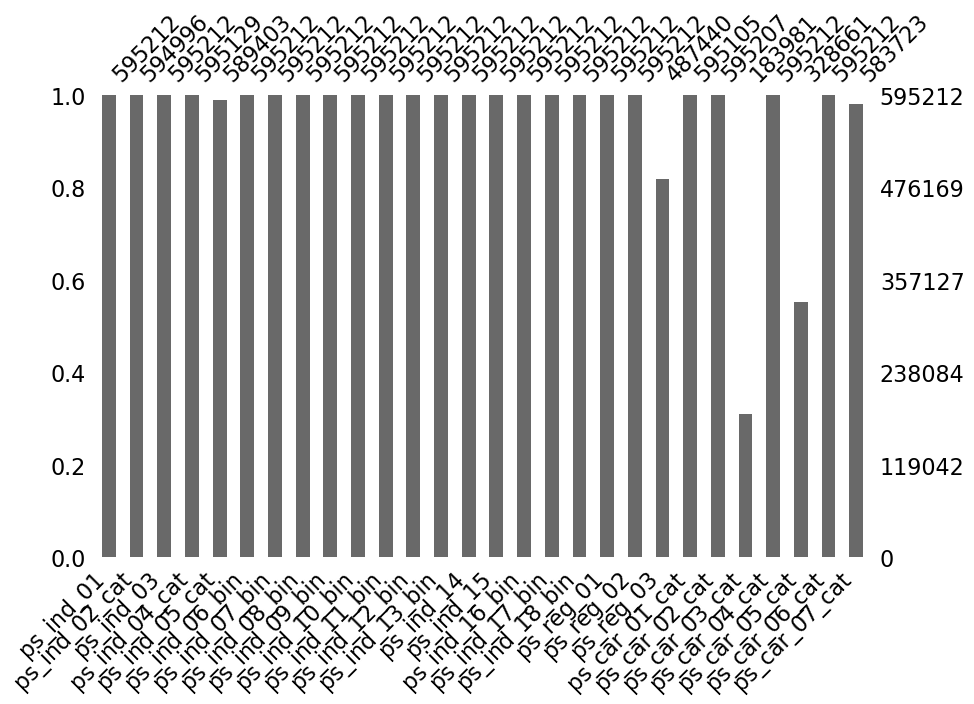

In [8]:
train_copy = train.copy().replace(-1, np.NaN)

msno.bar(df = train_copy.iloc[:, 1:29], figsize = (10, 6));

- To find out the real number of missing values, I changed the -1 to NaN.
- we can observe that ps_reg_03, ps_car_03_cat, ps_car_05_cat are having missing values.

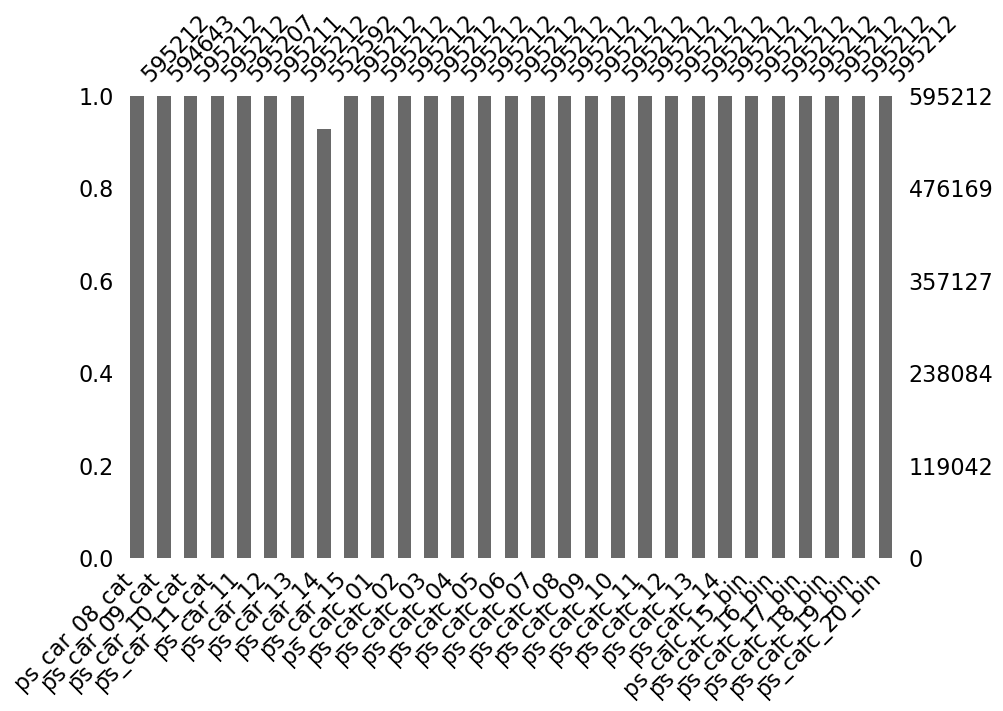

In [9]:
msno.bar(df = train_copy.iloc[:, 29:], figsize = (10, 6));

In [10]:
# "Feature Summary Table

def resumetable(df):
    print(f"Dataset shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ["data type"])
    summary["num_NaN"] = (df == -1).sum().values
    summary["num_Unique"] = df.nunique().values
    summary["Data Type"] = None
    for col in df.columns:
        if "bin" in col or col == "target":
            summary.loc[col, "Data Type"] = "Binary"
        elif "cat" in col:
            summary.loc[col, "Data Type"] = "Nominal"
        elif df[col].dtype == float:
            summary.loc[col, "Data Type"] = "Continuous"
        elif df[col].dtype == int:
            summary.loc[col, "Data Type"] = "Ordinal"

    return summary

In [11]:
summary = resumetable(train)
summary

Dataset shape: (595212, 58)


,data type,num_NaN,num_Unique,Data Type
target,int64,0,2,Binary
ps_ind_01,int64,0,8,Ordinal
ps_ind_02_cat,int64,216,5,Nominal
ps_ind_03,int64,0,12,Ordinal
ps_ind_04_cat,int64,83,3,Nominal
ps_ind_05_cat,int64,5809,8,Nominal
ps_ind_06_bin,int64,0,2,Binary
ps_ind_07_bin,int64,0,2,Binary
ps_ind_08_bin,int64,0,2,Binary
ps_ind_09_bin,int64,0,2,Binary


### 1.1 Visualization

In [12]:
def write_percent(ax, total_size):
    """Iterates over shape objects and 
    displays the target value ratio at the top of each bar"""
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size * 100

        ax.text(x = left_coord + width/2.0,
                y = height + total_size * 0.001,
                s = f"{percent: 1.1f}%",
                ha = "center")

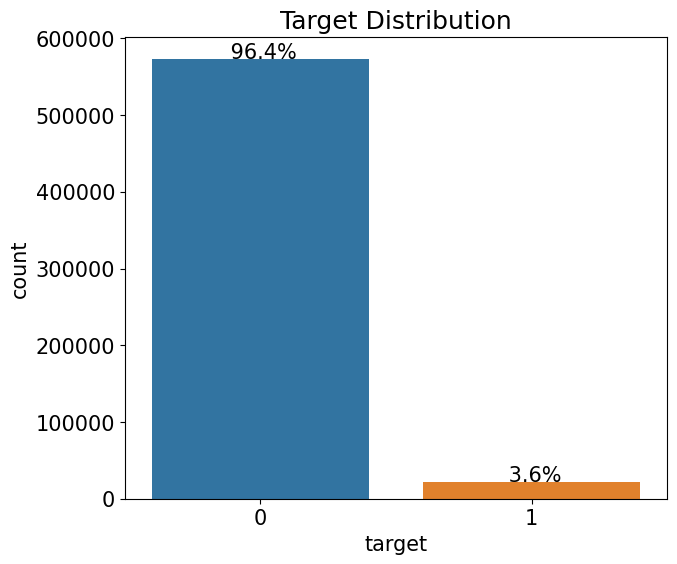

In [13]:
mpl.rc("font", size = 15)
plt.figure(figsize = (7, 6))

ax = sns.countplot(x = "target", data = train)
write_percent(ax, len(train))
ax.set_title("Target Distribution");

- The target value is imbalanced, making it crucial to accurately predict the minority target value, 1.
- Therefore, the proportion of target value 1 for each unique value of the features is checked to determine whether the feature is necessary for modeling.

In [14]:
# Binary features

def plot_target_ratio_by_features(df, features, num_rows, num_cols, size = (12, 18)):
    mpl.rc("font", size = 9)
    plt.figure(figsize = size)
    grid = gridspec.GridSpec(num_rows, num_cols)
    plt.subplots_adjust(wspace = 0.3, hspace = 0.3)

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        sns.barplot(x = feature, y = "target", data = df, palette = "Set2", ax = ax)

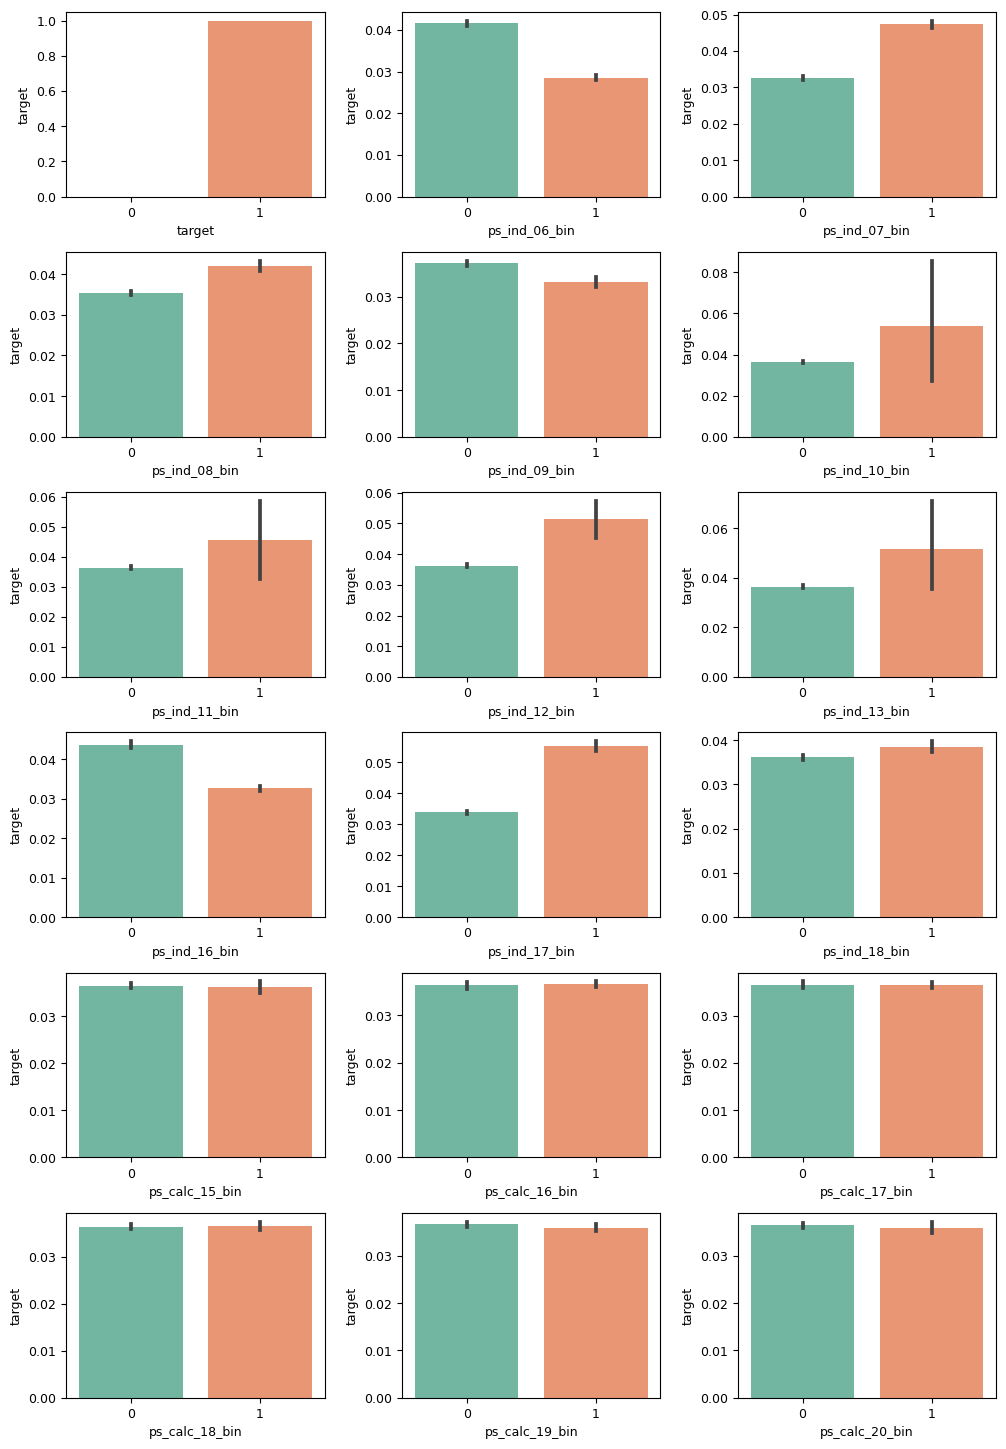

In [42]:
bin_features = summary[summary["Data Type"] == "Binary"].index
plot_target_ratio_by_features(train, bin_features, 6, 3)

- For the `ps_ind_06_bin` feature, the graph shows that when the value is 0, the proportion of target value 1 is 4%, while when the value is 1, the proportion is approximately 3%. This indicates that the target value proportions differ by unique values, meaning this feature has predictive power for estimating the target value. Additionally, the narrow confidence intervals suggest that this feature is statistically reliable and beneficial for modeling.
- On the other hand, `ps_ind_10_bin` to `ps_ind_13_bin` have wide confidence intervals, making them statistically less reliable.
- Similarly, `ps_calc_15_bin` to `ps_calc_20_bin` do not show differences in the target value proportions across unique values, indicating low predictive power for the target value.

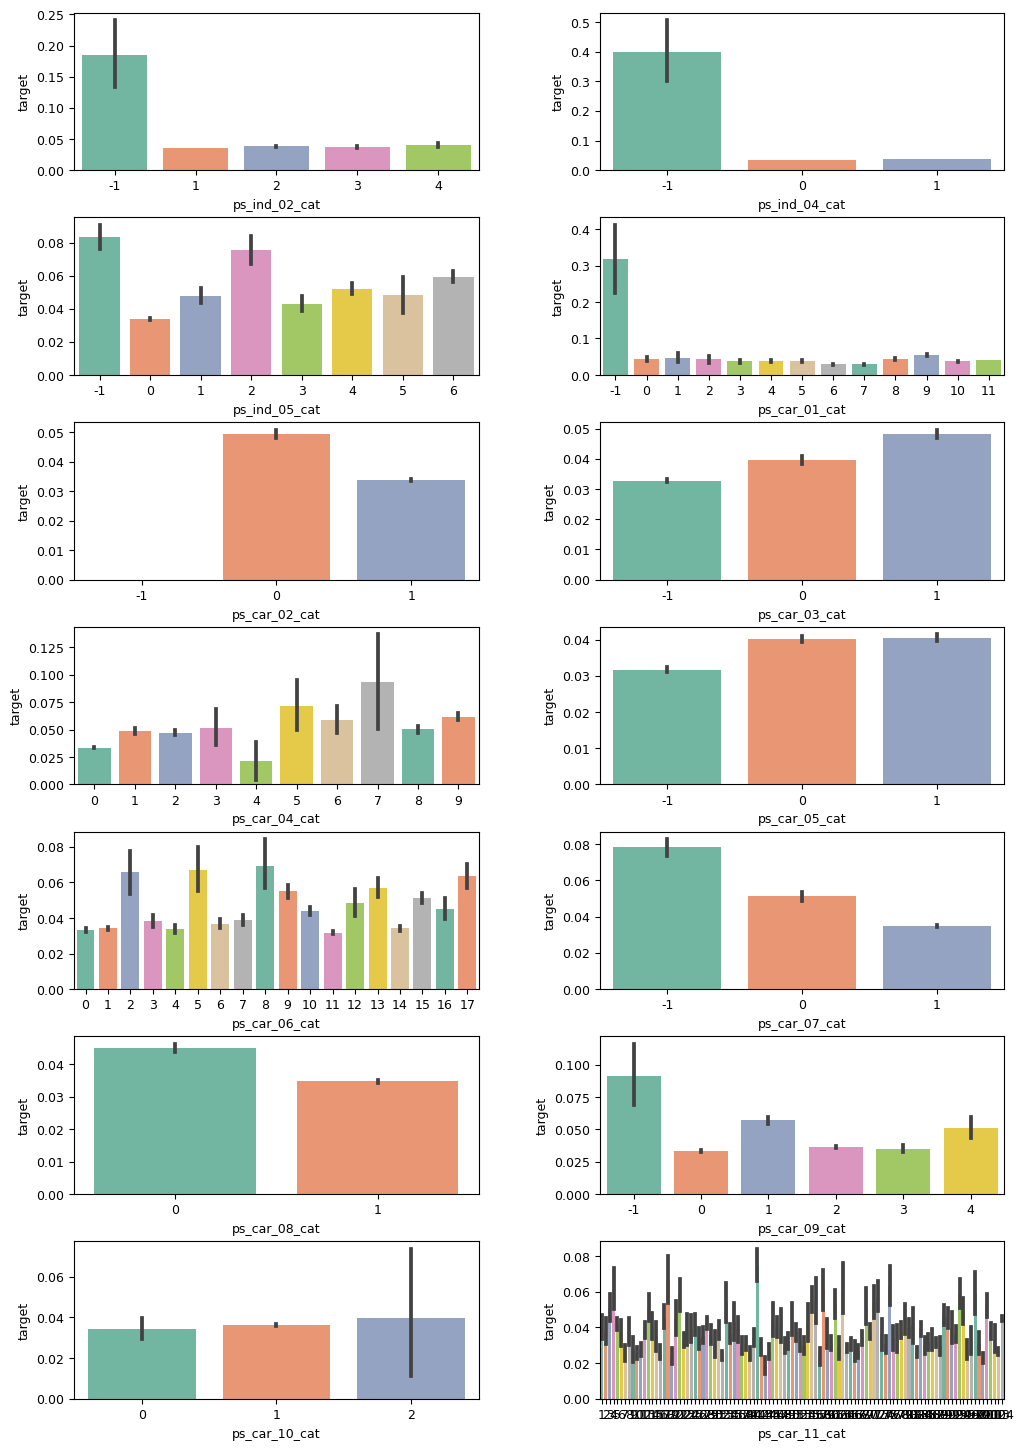

In [15]:
# nominal features

nom_features = summary[summary["Data Type"] == "Nominal"].index
plot_target_ratio_by_features(train, nom_features, 7, 2)

- Many features include the value -1, which represents missing data.
- For the `ps_ind_02_cat` feature, the proportion of target value 1 for the missing value (-1) is larger than for other unique values. Even considering the wide confidence interval, the proportion is noticeably higher. Since the missing value itself appears to have predictive power for the target value, it will be kept as is for modeling.
- All nominal features will be used because the differences in the proportion of target value 1 among their unique values are clear.